In [4]:
%pip install requests beautifulsoup4 lxml pandas matplotlib

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.1 MB 2.6 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.1 MB 2.8 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.1 MB 2.3 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.1 MB 2.3 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.1 MB 2.3 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.1 MB 2.3 MB/s eta 0:00:01
   ----------------------- ---------------- 2.4/4.1 MB 1.4 MB/s eta 0:00:02
   ------------------------- -------------- 2.6/4.1 MB 1.4 MB/s eta 0:00:02
   ---------------------------- ----------- 2.9/4.1 MB 1.4 MB/s eta 0:00:01
   ------------------------------ --------- 3.1/4.1 MB 1.4 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.1 MB 1.4 MB/s eta 0:00:01
   -----------------------

In [1]:
import random
import re
import time
from datetime import datetime, timezone
from urllib.parse import quote_plus, urljoin

import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
#choose amazon product
BASE_URL = "https://www.amazon.in"
SEARCH_QUERY = "wireless mouse"
NUMBER_OF_PAGES = 1
DELAY_SECONDS = 3

if not 1 <= NUMBER_OF_PAGES <= 5:
    raise ValueError("NUMBER_OF_PAGES must be between 1 and 5")

if DELAY_SECONDS < 2:
    raise ValueError("DELAY_SECONDS must be at least 2")

print("Search products:", SEARCH_QUERY)
print("Number of pages:", NUMBER_OF_PAGES)
    

Search products: wireless mouse
Number of pages: 1


In [4]:
#create the request session
session = requests.session()

session.headers.update({
     "Accept-Language": "en-IN,en-GB;q=0.9,en;q=0.8",
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
})
print("Request session created successfully")

Request session created successfully


In [7]:
def clean_text(element):
    if element:
        return element.get_text(" ", strip=True)
    return None


def clean_price(value):
    if not value:
        return None

    number = re.sub(r"[^0-9.]", "", value)

    try:
        return float(number)
    except ValueError:
        return None


def first_number(value, convert_to=float):
    if not value:
        return None

    match = re.search(r"[0-9][0-9,.]*", value)

    if not match:
        return None

    try:
        number = match.group(0).replace(",", "")
        return convert_to(number)
    except ValueError:
        return None


print("Helper functions created successfully")

Helper functions created successfully


In [8]:
#Request one Amazon search page
search_url = (
    f"{BASE_URL}/s?"
    f"k={quote_plus(SEARCH_QUERY)}&page=1"
)

print("Requesting:", search_url)

response = session.get(search_url, timeout=20)

print("Status code:", response.status_code)
print("Download characters:", len(response.text))

if "Enter the characyers you see below" in response.text:
    print("Amazon returned a CAPTCHA. Stop and try again later.")
elif response.status_code == 200:
    print("Amazon page download successfully")
else:
    print("Amazon did not allow the request")
    

Requesting: https://www.amazon.in/s?k=wireless+mouse&page=1
Status code: 200
Download characters: 1303853
Amazon page download successfully


In [9]:
#Find the product cards
soup = BeautifulSoup(response.text, "lxml")

product_cards = soup.select(
    "div[data-component-type='s-search-result']"
)

print("Product cards found:", len(product_cards))

Product cards found: 16


In [12]:
#Extract the first product
first_card = product_cards[0]

title_element = first_card.select_one("h2 span")
price_element = first_card.select_one(
    "span.a-price span.a-offscreen"
)
rating_element = first_card.select_one(
    "span.a-icon-alt"
)
review_element = first_card.select_one(
    "span.a-size-base.s-underline-text"
)

title = clean_text(title_element)
price = clean_price(clean_text(price_element))
rating = first_number(
    clean_text(rating_element), float
)
reviews = first_number(
    clean_text(review_element), int
)

print("Title:", title)
print("Price:", price)
print("Rating:", rating)
print("Review:", reviews)

Title: Portronics Toad 23 Wireless Optical Mouse with 2.4GHz, USB Nano Dongle, Optical Orientation, Click Wheel, Adjustable DPI(Black)
Price: 279.0
Rating: 4.0
Review: None


In [13]:
#Fix the review count
review_element = first_card.select_one(
    "a[aria-label*='rating']"
)

if review_element:
    review_text = (
        review_element.get("aria-label")
        or clean_text(review_element)
    )
else:
    review_text = None
reviews = first_number(review_text, int)

print("Review text:", review_text)
print("Review count:", reviews)
    

Review text: 4.0 out of 5 stars, rating details
Review count: None


In [14]:
#Find the exact review label
labels = []

for element in first_card.select("[aria-label]"):
    label = element.get("aria-label")

    if label:
        labels.append(label)

for label in labels:
    print(label)

Amazon's Choice
Portronics Toad 23 Wireless Optical Mouse with 2.4GHz, USB Nano Dongle, Optical Orientation, Click Wheel, Adjustable DPI(Black)
4.0 out of 5 stars, rating details
16,195 ratings
Add to cart


In [16]:
review_element = first_card.select_one(
    "[aria-label*='ratings']"
)

if review_element:
    review_text = review_element.get("aria-label")
else:
    review_text = None

reviews = first_number(review_text, int)

print("Review text:", review_text)
print("Review count:", reviews)

Review text: 16,195 ratings
Review count: 16195


In [18]:
products = []

collected_at = datetime.now(
    timezone.utc
).isoformat()

for card in product_cards:
    title_element = card.select_one("h2 span")
    title = clean_text(title_element)

    if not title:
        continue

    price_element = card.select_one(
        "span.a-price span.a-offscreen"
    )
    rating_element = card.select_one(
        "span.a-icon-alt"
    )
    review_element = card.select_one(
        "[aria-label*='ratings']"
    )
    link_element = card.select_one("h2 a[href]")

    price_text = clean_text(price_element)
    rating_text = clean_text(rating_element)

    if review_element:
        review_text = review_element.get("aria-label")
    else:
        review_text = None

    if link_element:
        relative_url = link_element.get("href")
        product_url = urljoin(BASE_URL, relative_url)
    else:
        product_url = None

    products.append({
        "asin": card.get("data-asin"),
        "title": title,
        "price_inr": clean_price(price_text),
        "rating_out_of_5": first_number(
            rating_text, float
        ),
        "review_count": first_number(
            review_text, int
        ),
        "product_url": product_url,
        "search_query": SEARCH_QUERY,
        "page": 1,
        "collected_at_utc": collected_at
    })

print("Products extracted:", len(products))

products[:2]

Products extracted: 16


[{'asin': 'B0B296NTFV',
  'title': 'Portronics Toad 23 Wireless Optical Mouse with 2.4GHz, USB Nano Dongle, Optical Orientation, Click Wheel, Adjustable DPI(Black)',
  'price_inr': 279.0,
  'rating_out_of_5': 4.0,
  'review_count': 16195,
  'product_url': None,
  'search_query': 'wireless mouse',
  'page': 1,
  'collected_at_utc': '2026-08-27T10:32:24.759460+00:00'},
 {'asin': 'B0CQRNWJM2',
  'title': 'ZEBRONICS Blanc Slim Wireless Mouse with Rechargeable Battery, BT + 2.4GHz, 4 Buttons, 800/1200/1600 DPI, Silent Operation, Multicolor LED Lights',
  'price_inr': None,
  'rating_out_of_5': 4.0,
  'review_count': 8956,
  'product_url': None,
  'search_query': 'wireless mouse',
  'page': 1,
  'collected_at_utc': '2026-08-27T10:32:24.759460+00:00'}]

In [21]:
#Create and clean the DataFrame
amazon_df = pd.DataFrame(products)

amazon_df["product_url"] = amazon_df["asin"].apply(
    lambda asin:(
    f"{BASE_URL}/dp/{asin}"
    if pd.notna(asin) and asin
    else None
)
)

amazon_df = amazon_df.drop_duplicates(
    subset=["asin", "title"],
    keep="first"
)

amazon_df["price_inr"] = pd.to_numeric(
    amazon_df["price_inr"],
    errors="coerce"
)

amazon_df["rating_out_of_5"] = pd.to_numeric(
    amazon_df["rating_out_of_5"],
    errors="coerce"
)

amazon_df["Review_count"] = pd.to_numeric(
    amazon_df["review_count"],
    errors="coerce"
).astype("Int64")

amazon_df = amazon_df.sort_values(
    "price_inr",
    na_position="last"
).reset_index(drop=True)

print("DataFrame shape:", amazon_df.shape)

display(amazon_df.head(10))




DataFrame shape: (16, 10)


,asin,title,price_inr,rating_out_of_5,review_count,product_url,search_query,page,collected_at_utc,Review_count
0,B0GHYBDYW5,"Zebronics Wireless Mouse, 2.4GHz, 3200 DPI, 3 ...",229.0,3.8,3800,https://www.amazon.in/dp/B0GHYBDYW5,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,3800
1,B0GHY1645B,"Zebronics Wireless Mouse, 2.4GHz, 3200 DPI, 3 ...",249.0,3.8,3800,https://www.amazon.in/dp/B0GHY1645B,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,3800
2,B0DDTL9PB6,"ZEBRONICS Dash Pro 2.4GHz Wireless Mouse, Upto...",269.0,3.7,1385,https://www.amazon.in/dp/B0DDTL9PB6,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,1385
3,B0B296NTFV,Portronics Toad 23 Wireless Optical Mouse with...,279.0,4.0,16195,https://www.amazon.in/dp/B0B296NTFV,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,16195
4,B0GCDTYXNZ,Zen-Slim Wireless Mouse with Rechargeable Batt...,299.0,4.6,26,https://www.amazon.in/dp/B0GCDTYXNZ,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,26
5,B0DGGW7FFS,Portronics Toad 34 Wireless Mouse with 2.4 GHz...,311.0,4.0,1790,https://www.amazon.in/dp/B0DGGW7FFS,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,1790
6,B0DXNY14GL,HP M290 Wireless Mouse (AB3C7AA),419.0,3.8,936,https://www.amazon.in/dp/B0DXNY14GL,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,936
7,B0GDTSH5BW,"Zebronics Wireless Mouse, Dual Mode 2.4GHz + B...",429.0,4.0,8956,https://www.amazon.in/dp/B0GDTSH5BW,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,8956
8,B01J0XWYKQ,"Logitech B170 USB Mouse,12-Months Battery Life...",495.0,4.3,79062,https://www.amazon.in/dp/B01J0XWYKQ,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,79062
9,B0FKPXG5R8,Acer Bubble Wireless Mouse AMR100 | 2.4GHz Sil...,499.0,4.3,857,https://www.amazon.in/dp/B0FKPXG5R8,wireless mouse,1,2026-08-27T10:32:24.759460+00:00,857


In [22]:
print("DataFrame shape:",amazon_df.shape)

print("\ncolumn data types")
amazon_df.info()

print("\nMissing values:")
missing_values = amazon_df.isna().sum()

display(
    missing_values.to_frame(
        name="missing_values"
    )
)

DataFrame shape: (16, 10)

column data types
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   asin              16 non-null     str    
 1   title             16 non-null     str    
 2   price_inr         14 non-null     float64
 3   rating_out_of_5   16 non-null     float64
 4   review_count      16 non-null     int64  
 5   product_url       16 non-null     str    
 6   search_query      16 non-null     str    
 7   page              16 non-null     int64  
 8   collected_at_utc  16 non-null     str    
 9   Review_count      16 non-null     Int64  
dtypes: Int64(1), float64(2), int64(2), str(5)
memory usage: 5.1 KB

Missing values:


,missing_values
asin,0
title,0
price_inr,2
rating_out_of_5,0
review_count,0
product_url,0
search_query,0
page,0
collected_at_utc,0
Review_count,0


In [23]:
#Remove the duplicate column and save the CSV
amazon_df = amazon_df.drop(
    columns=["Review_count"],
    errors="ignore"
)

output_file = "amazon_wireless_mouse.csv"

amazon_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Final shape:", amazon_df.shape)
print("CSV saved successfully:", output_file)

Final shape: (16, 9)
CSV saved successfully: amazon_wireless_mouse.csv


In [26]:
priced_products = amazon_df.dropna(
    subset=["price_inr"]
)
print("Total products:", len(amazon_df))
print("Products with prices:", len(priced_products))

print(
    "Average price: ₹",
    round(priced_products["price_inr"].mean(), 2)
)

print(
    "Lowest price: ₹",
    priced_products["price_inr"].min()
)
print(
    "Highest price: ₹",
    priced_products["price_inr"].max()
)

print(
    "Average rating:",
    round(amazon_df["rating_out_of_5"].mean(), 2)
)

Total products: 16
Products with prices: 14
Average price: ₹ 432.5
Lowest price: ₹ 229.0
Highest price: ₹ 699.0
Average rating: 4.06


In [27]:
recommended_products = amazon_df[
    (amazon_df["rating_out_of_5"] >=4.0)
    & (amazon_df["review_count"] >= 100)
    & (amazon_df["price_inr"].notna())
].copy()

recommended_products = recommended_products.sort_values(
    by=["rating_out_of_5", "review_count"],
    ascending=[False, False]
)

display(
    recommended_products[
        [
            "title",
            "price_inr",
            "rating_out_of_5",
            "review_count"
        ]
        
    ].head(10)
)

,title,price_inr,rating_out_of_5,review_count
11,Arctic Fox Pureview Transparent Wireless and B...,659.0,4.4,9251
8,"Logitech B170 USB Mouse,12-Months Battery Life...",495.0,4.3,79062
13,Portronics Toad One Bluetooth Mouse with 2.4 G...,699.0,4.3,9814
9,Acer Bubble Wireless Mouse AMR100 | 2.4GHz Sil...,499.0,4.3,857
12,"Dell WM118 Wireless Mouse, 1000DPI, 2.4 Ghz wi...",674.0,4.1,16782
10,"Logitech M186 Wireless Mouse, 2.4GHz with USB ...",545.0,4.1,4602
3,Portronics Toad 23 Wireless Optical Mouse with...,279.0,4.0,16195
7,"Zebronics Wireless Mouse, Dual Mode 2.4GHz + B...",429.0,4.0,8956
5,Portronics Toad 34 Wireless Mouse with 2.4 GHz...,311.0,4.0,1790


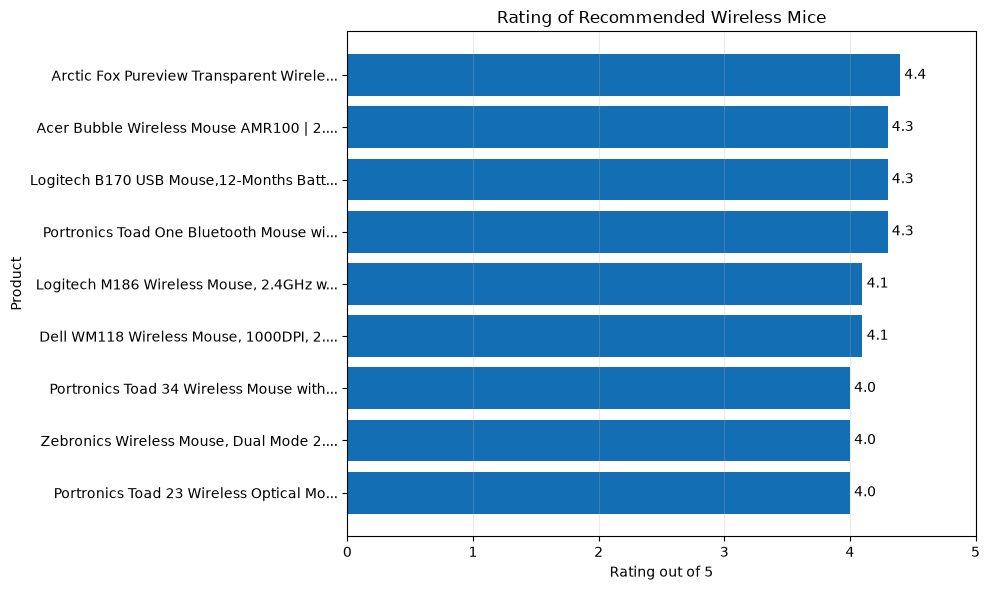

In [28]:
#Create a ratings chart
chart_data = recommended_products.copy()

chart_data["short_title"] = (
    chart_data["title"]
    .str.slice(0,38)
    + "..."
)

chart_data = chart_data.sort_values(
    "rating_out_of_5",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart_data["short_title"],
    chart_data["rating_out_of_5"],
    color="#146EB4"
)

plt.bar_label(
    bars,
    fmt="%.1f",
    padding=3
)

plt.title("Rating of Recommended Wireless Mice")
plt.xlabel("Rating out of 5")
plt.ylabel("Product")
plt.xlim(0, 5)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

Price and rating correlation: 0.51


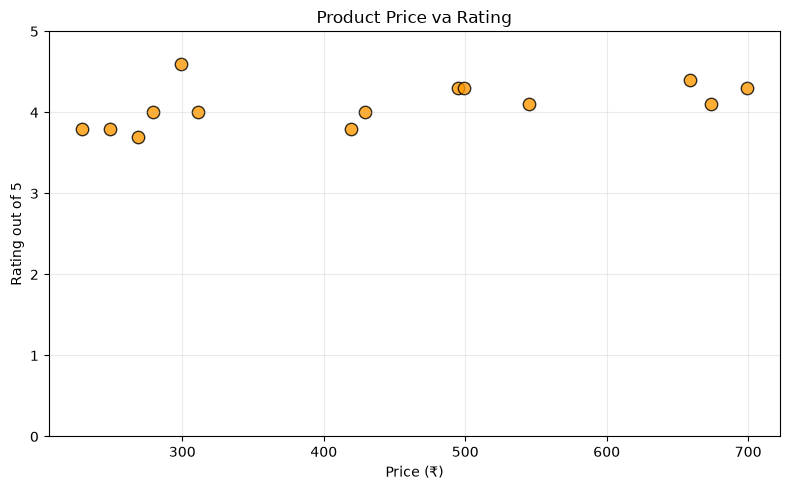

In [30]:
#Compare price and rating
scatter_data = amazon_df.dropna(
    subset=["price_inr", "rating_out_of_5"]
)

correlation = scatter_data[
    ["price_inr", "rating_out_of_5"]
].corr().iloc[0, 1]

print(
    "Price and rating correlation:",
    round(correlation, 2)
)

plt.figure(figsize= (8, 5))

plt.scatter(
    scatter_data["price_inr"],
    scatter_data["rating_out_of_5"],
    color="#FF9900",
    edgecolor="black",
    s=80,
    alpha=0.8
)

plt.title("Product Price va Rating")
plt.xlabel("Price (₹)")
plt.ylabel("Rating out of 5")
plt.ylim(0, 5)
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "amazon_price_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
highest_rated = amazon_df.loc[
    amazon_df["rating_out_of_5"].idxmax()
]

most_reviewed = amazon_df.loc[
    amazon_df["review_count"].idxmax()
]

lowest_priced_recommended = (
    recommended_products
    .sort_values("price_inr")
    .iloc[0]
)

print("FINAL PROJECT FINDINGS")
print("-" * 40)

print(
    "Price-rating correlation:",
    round(correlation, 2)
)

print(
    "\nHighest-rated product:",
    highest_rated["title"]
)
print(
    "Rating:",
    highest_rated["rating_out_of_5"]
)

print(
    "\nMost-reviewed product:",
    most_reviewed["title"]
)
print(
    "Reviews:",
    most_reviewed["review_count"]
)

print(
    "\nLowest-priced recommended product:",
    lowest_priced_recommended["title"]
)
print(
    "Price: ₹",
    lowest_priced_recommended["price_inr"]
)

FINAL PROJECT FINDINGS
----------------------------------------
Price-rating correlation: 0.51

Highest-rated product: Zen-Slim Wireless Mouse with Rechargeable Battery, BT + 2.4GHz, 4 Buttons, 800/1200/1600 DPI, Silent Operation, Multicolor LED Lights
Rating: 4.6

Most-reviewed product: Logitech B170 USB Mouse,12-Months Battery Life, Ambidextrous, PC/Mac/Laptop - Black
Reviews: 79062

Lowest-priced recommended product: Portronics Toad 23 Wireless Optical Mouse with 2.4GHz, USB Nano Dongle, Optical Orientation, Click Wheel, Adjustable DPI(Black)
Price: ₹ 279.0


In [32]:
## Project Conclusion

This project collected and analyzed 16 wireless-mouse listings from Amazon India using Python, Requests, BeautifulSoup, and Pandas.

### Key Findings

- Fourteen products displayed valid prices.
- The average product price was ₹432.50.
- Prices ranged from ₹229 to ₹699.
- The average product rating was 4.06 out of 5.
- Price and rating had a moderate positive correlation of 0.51.
- Zen-Slim Wireless Mouse had the highest rating of 4.6.
- Logitech B170 was the most-reviewed product with 79,062 ratings.
- Portronics Toad 23 was the lowest-priced recommended product at ₹279.

### Limitation

The analysis uses only one search-results page and represents a small snapshot. Amazon listings, prices, ratings, and page structure can change over time.

SyntaxError: invalid character '₹' (U+20B9) (2403443525.py, line 8)